In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import argparse

In [47]:
plt.rcParams.update({
    "font.size": 14,                 # 全局字号
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",         # 刻度朝内
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (4, 3),        # 图片默认大小
})

In [48]:
T = 0.04
data_dir = f"T_{T}"

In [49]:
# # 1. Optical Conductivity
# opt_file = os.path.join(data_dir, "spectra_opt_cond.csv")

# df_opt = pd.read_csv(opt_file)

# plt.figure(figsize=(6, 5), dpi=300)
# plt.plot(df_opt['omega'], df_opt['Re_Sigma'], 'b-', label=r'Re $\sigma(\omega)$')
# plt.fill_between(df_opt['omega'], 
#                     df_opt['Re_Sigma'] - df_opt['Error'], 
#                     df_opt['Re_Sigma'] + df_opt['Error'], 
#                     color='b', alpha=0.3)

# plt.xlabel(r'$\omega$')
# plt.ylabel(r'Re $\sigma(\omega)$')
# # plt.title('Optical Conductivity')
# plt.xlim(left=0)
# # plt.xlim(0, 0.1)
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# # plt.savefig(os.path.join(data_dir, "plot_opt_cond.png"), dpi=300)
# plt.show()

In [50]:
# 1/df_opt['Re_Sigma'][0]

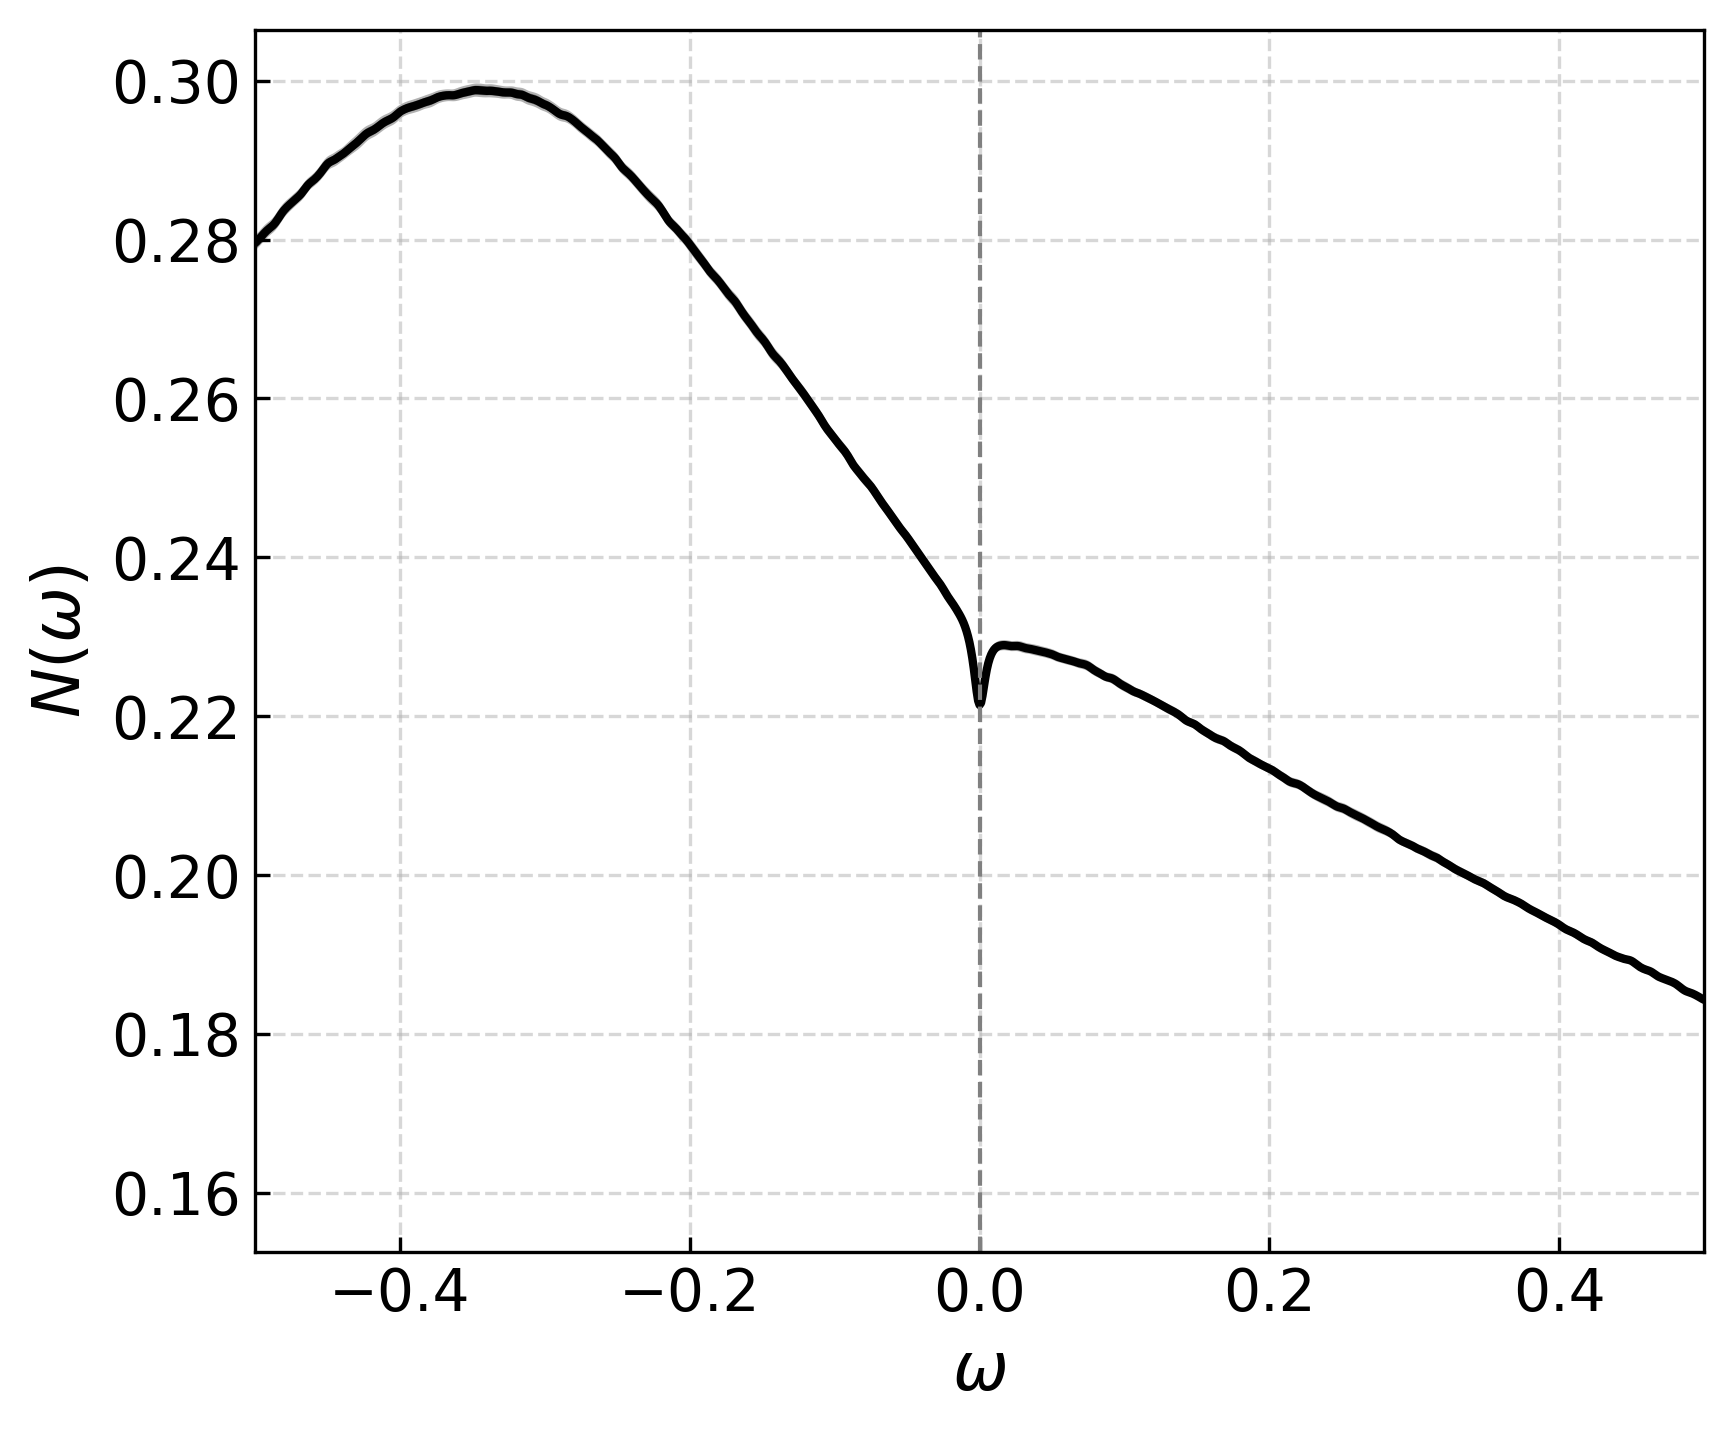

In [51]:
# 2. DOS
dos_file = os.path.join(data_dir, "spectra_dos.csv")

df_dos = pd.read_csv(dos_file)

plt.figure(figsize=(6, 5), dpi=300)
plt.plot(df_dos['omega'], df_dos['DOS'], 'k-', label=r'$N(\omega)$')
plt.fill_between(df_dos['omega'], 
                    df_dos['DOS'] - df_dos['DOS_Error'], 
                    df_dos['DOS'] + df_dos['DOS_Error'], 
                    color='k', alpha=0.3)

plt.xlabel(r'$\omega$')
plt.ylabel(r'$N(\omega)$')
# plt.xlim(-3, 3)
plt.xlim(-0.5, 0.5)
# plt.title('Density of States')
# 画一条竖线在 omega=0
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig(os.path.join(data_dir, "plot_dos.png"), dpi=300)
plt.show()

In [52]:
# Delta = 0.1165
# tp = -0.35
# mu = -1.4

Delta = 0.092
tp = -0.35
mu = -1.08

In [53]:
Delta_k = Delta * 2
epsilon_k = 4*tp - mu
E_k = np.sqrt(epsilon_k**2 + Delta_k**2)
u_k2 = 0.5 * (1 + epsilon_k / E_k)
v_k2 = 0.5 * (1 - epsilon_k / E_k)

In [54]:
eta = 5 / 24**2
delta_peak = 1/(np.pi*eta)

u_peak = u_k2 * delta_peak
v_peak = v_k2 * delta_peak

In [55]:
# # 2. DOS
# dos_file = os.path.join(data_dir, "spectra_dos.csv")

# df_dos = pd.read_csv(dos_file)

# plt.figure(dpi=300)
# plt.plot(df_dos['omega'], df_dos['DOS_AN'], 'k-')
# plt.fill_between(df_dos['omega'], 
#                     df_dos['DOS_AN'] - df_dos['DOS_AN_Error'], 
#                     df_dos['DOS_AN'] + df_dos['DOS_AN_Error'], 
#                     color='k', alpha=0.3)

# plt.xlabel(r'$\omega$')
# plt.ylabel(r'$A(\mathbf{k}=\mathbf{M},\omega)$')
# plt.xlim(-0.8, 0.8)
# plt.ylim(0, 3.1)

# plt.axvline(0, color='gray', linestyle='--', linewidth=1)
# # plt.axvline(E_k, color='red', linestyle='--', linewidth=1, label=r'$+E_k$')
# # plt.axvline(-E_k, color='blue', linestyle='--', linewidth=1, label=r'$-E_k$')
# # plt.axhline(u_peak, color='red', linestyle=':', linewidth=1, label=r'$u_k^2/\pi\eta$')
# # plt.axhline(v_peak, color='blue', linestyle=':', linewidth=1, label=r'$v_k^2/\pi\eta$')
# # plt.axhline(delta_peak/2, color='green', linestyle=':', linewidth=1, label=r'$1/(2\pi\eta)$')

# plt.show()

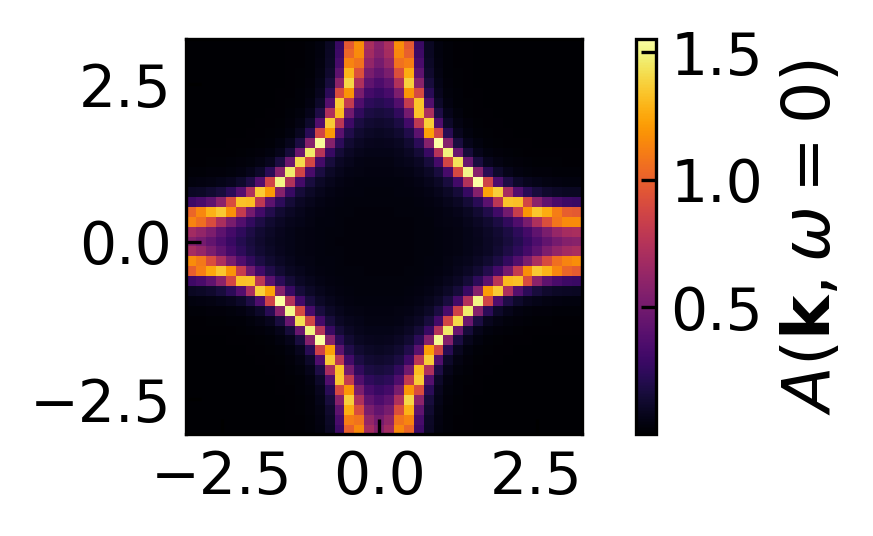

In [56]:
# 3. Spectral Function A(k) Heatmap
ak_file = os.path.join(data_dir, "spectra_ak0.csv")

df_ak = pd.read_csv(ak_file)

# 使用 pivot table 重塑数据
# index=ky (物理坐标), columns=kx (物理坐标), values=A_val
# 这样我们可以直接拿到用于绘图的物理坐标轴
pivot_table = df_ak.pivot(index='ky', columns='kx', values='A_val')

# 确保按数值排序 (防止csv读取顺序乱掉)
pivot_table.sort_index(ascending=True, inplace=True) # y轴排序
pivot_table = pivot_table.reindex(sorted(pivot_table.columns), axis=1) # x轴排序

# 提取网格坐标
# kx_vals 和 ky_vals 是每个像素的中心坐标
kx_vals = pivot_table.columns.values.astype(float)
ky_vals = pivot_table.index.values.astype(float)
Z = pivot_table.values

# 生成网格矩阵 (Meshgrid)
# 这里的 X, Y 对应的是 Z 中每个点的中心位置
X, Y = np.meshgrid(kx_vals, ky_vals)

plt.figure(figsize=(3, 2), dpi=300)

# 关键修改：使用 pcolormesh + shading='nearest'
# rasterized=True 非常重要！防止保存为 PDF/SVG 时文件变得巨大且渲染缓慢
pcm = plt.pcolormesh(X, Y, Z, 
                        shading='nearest', 
                        cmap='inferno', 
                        rasterized=True)

cbar = plt.colorbar(pcm)
cbar.set_label(r'$A(\mathbf{k}, \omega=0)$')

# plt.xlabel(r'$k_x$')
# plt.ylabel(r'$k_y$')
# plt.title('Fermi Surface')

# 强制坐标范围为 [-pi, pi] (或者根据你的数据范围)
plt.axis('scaled') # 保证 x 和 y 轴比例一致 (正方形像素)
# plt.xlim(-np.pi, np.pi)
# plt.ylim(-np.pi, np.pi)

# 绘制布里渊区的高对称线 (可选)
# 画个框或者十字线辅助参考
# plt.axhline(0, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
# plt.axvline(0, color='white', linestyle='--', linewidth=0.5, alpha=0.7)

# 标注 (pi, 0) 和 (0, pi)
# plt.plot([np.pi, -np.pi], [0, 0], 'w+', markersize=5, alpha=0.5)
# plt.plot([0, 0], [np.pi, -np.pi], 'w+', markersize=5, alpha=0.5)

plt.tight_layout()
# plt.savefig(os.path.join(data_dir, "plot_fermi_surface.png"), dpi=300)
plt.show()
# print("  -> plot_fermi_surface.png saved (centered pixels).")

Path Analysis Results
Segment M(pi,0) -> X(pi,pi):
  Peak Value: 1.1590 +/- 0.0176
  Location:   kx=3.14, ky=0.31
--------------------------------------------------
Segment X(pi,pi) -> Gamma(0,0):
  Peak Value: 1.4325 +/- 0.0172
  Location:   kx=1.23, ky=1.23
  (Note: d-wave Node is usually at pi/2, pi/2)


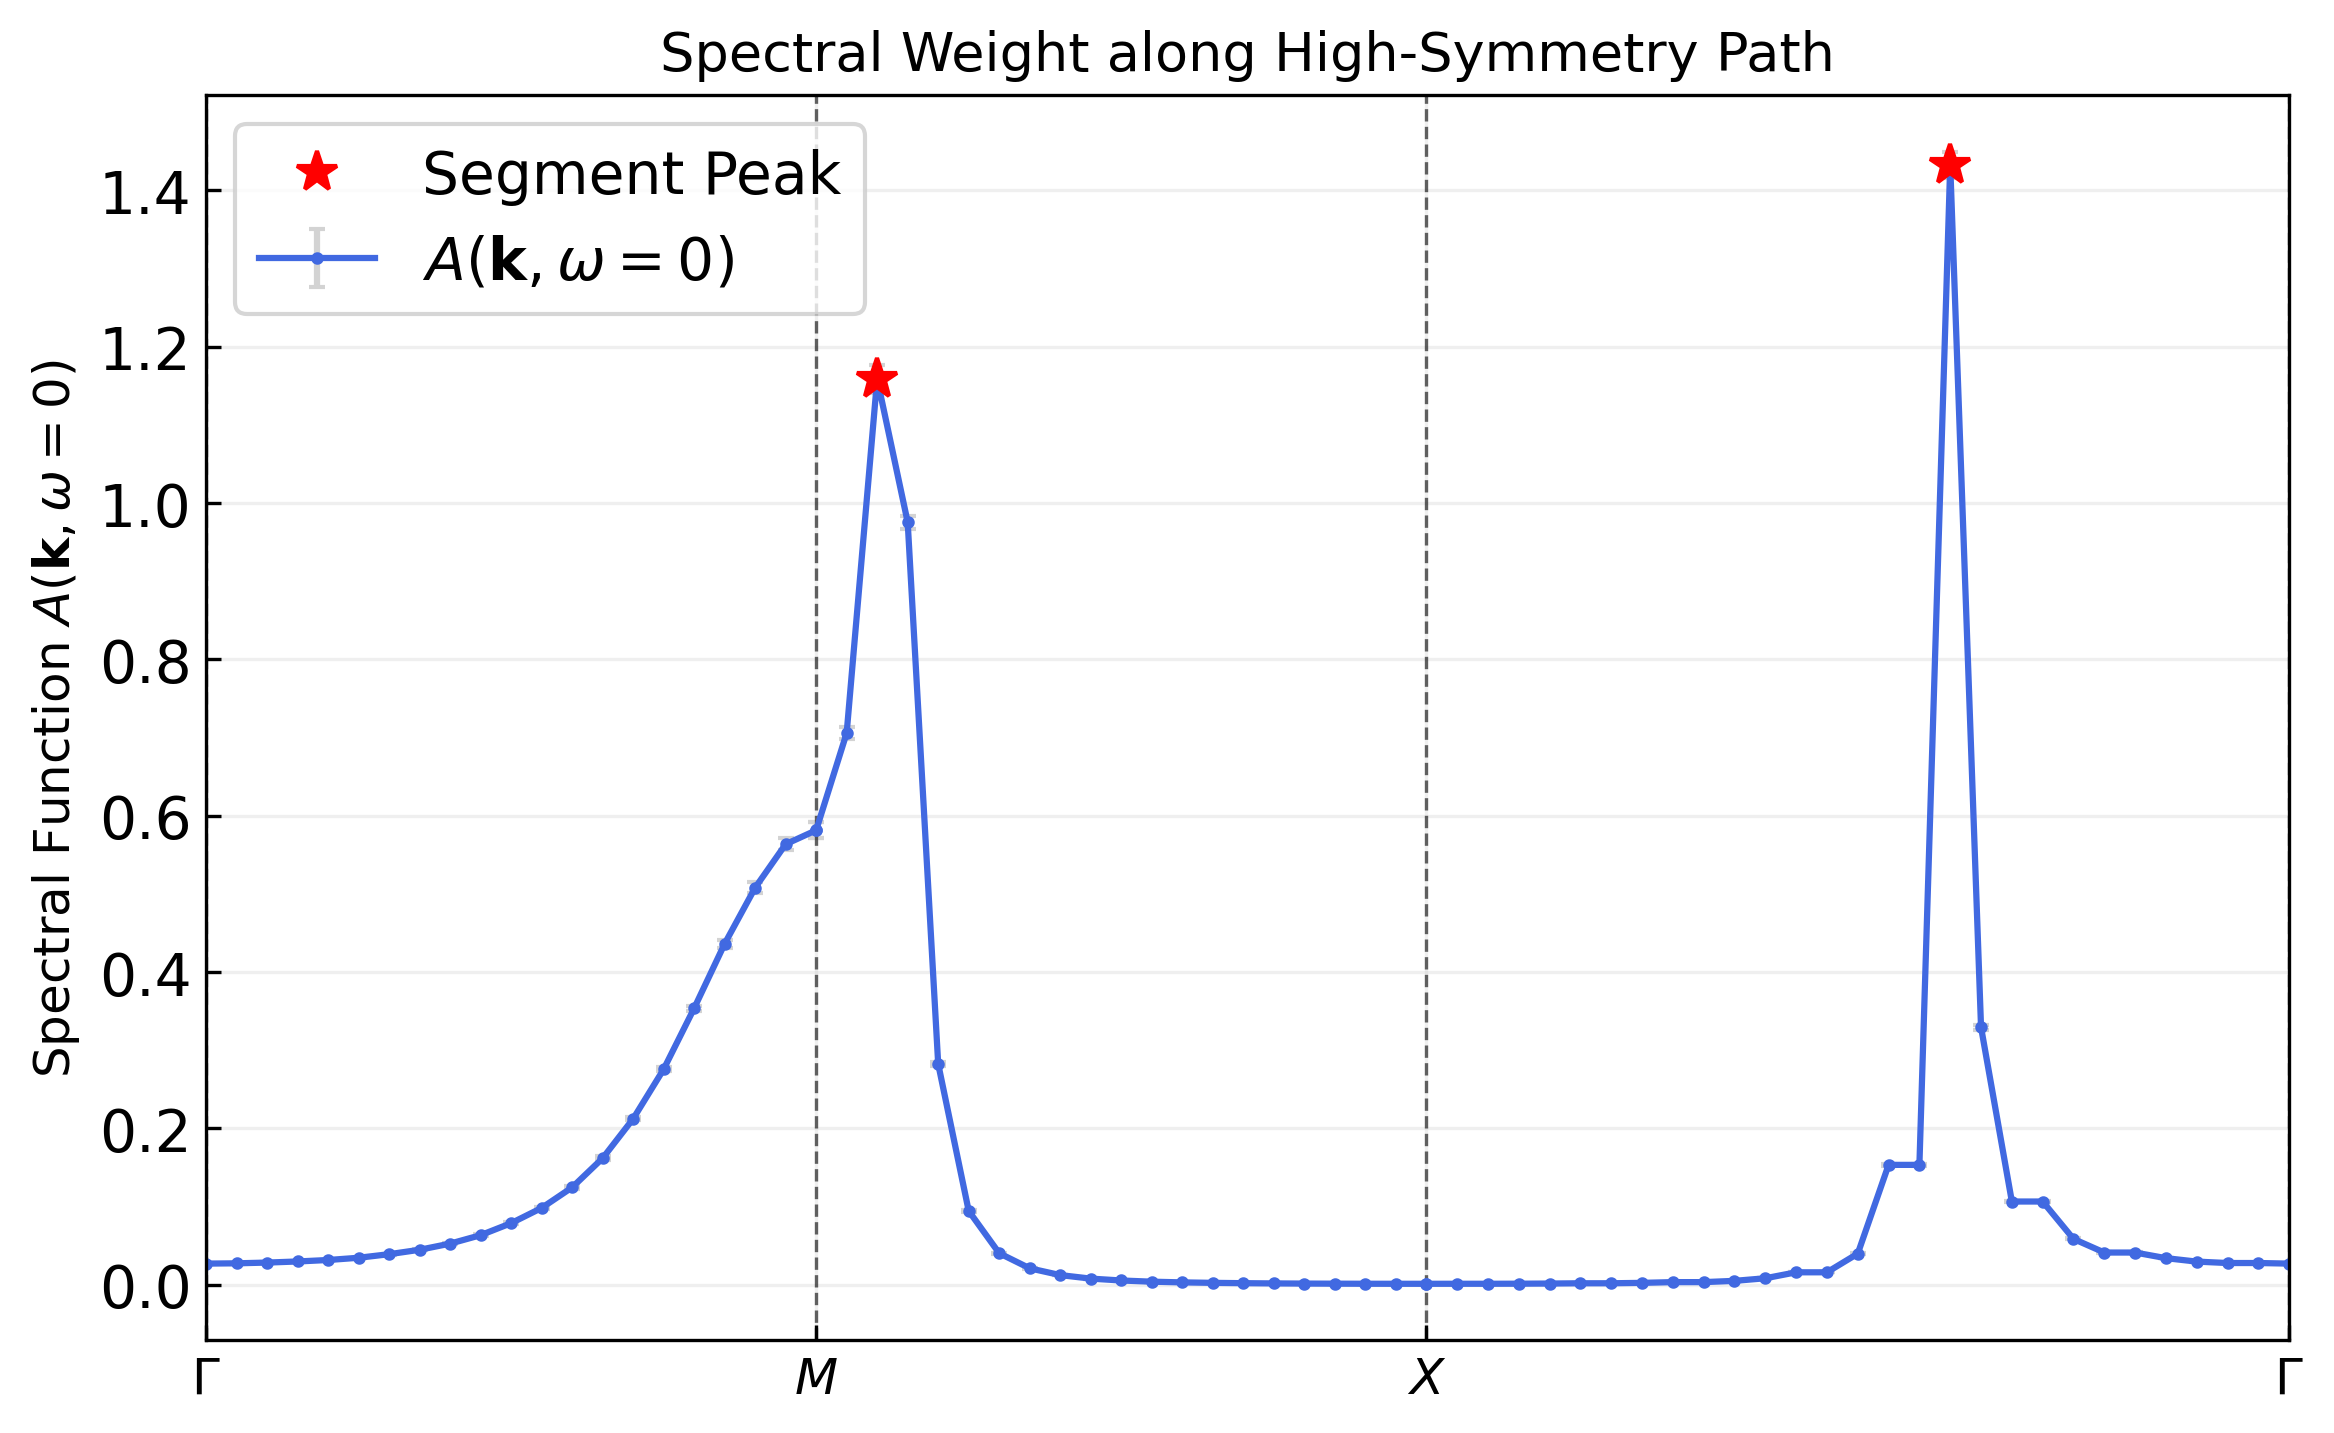

In [57]:
def read_csv_to_pivot(data_dir, filename, value_col='A_val'):
    file_path = os.path.join(data_dir, filename)
    df = pd.read_csv(file_path)
    pivot_table = df.pivot(index='ky', columns='kx', values=value_col)
    pivot_table.sort_index(ascending=True, inplace=True) 
    pivot_table = pivot_table.reindex(sorted(pivot_table.columns), axis=1) 
    kx_vals = pivot_table.columns.values.astype(float)
    ky_vals = pivot_table.index.values.astype(float)
    Z = pivot_table.values
    return kx_vals, ky_vals, Z

def get_nearest_val(k_x_target, k_y_target, kx_array, ky_array, data_matrix, error_matrix):
    """
    找到网格中距离 (k_x_target, k_y_target) 最近的点，返回索引、实际坐标和数值
    """
    idx_x = (np.abs(kx_array - k_x_target)).argmin()
    idx_y = (np.abs(ky_array - k_y_target)).argmin()
    real_kx = kx_array[idx_x]
    real_ky = ky_array[idx_y]
    val = data_matrix[idx_y, idx_x]
    err = error_matrix[idx_y, idx_x]
    return real_kx, real_ky, val, err

kx_vals, ky_vals, Z = read_csv_to_pivot(data_dir, "spectra_ak0.csv", value_col='A_val')
kx_vals, ky_vals, Zerr = read_csv_to_pivot(data_dir, "spectra_ak0.csv", value_col='Error')

def extract_path_segment(start_pt, end_pt, num_steps, kx_vals, ky_vals, Z, Zerr):
    """
    沿着从 start_pt 到 end_pt 的直线提取 num_steps 个点的数据
    返回: dists(路径距离数组), vals(数值数组), errs(误差数组)
    """
    # 生成路径上的参数坐标
    kxs = np.linspace(start_pt[0], end_pt[0], num_steps)
    kys = np.linspace(start_pt[1], end_pt[1], num_steps)
    
    vals = []
    errs = []
    
    # 对路径上每一点找最近的网格点数据
    for kx_t, ky_t in zip(kxs, kys):
        _, _, val, err = get_nearest_val(kx_t, ky_t, kx_vals, ky_vals, Z, Zerr)
        vals.append(val)
        errs.append(err)
        
    vals = np.array(vals)
    errs = np.array(errs)
    
    # 计算物理距离 (用于x轴绘图)
    dk = np.sqrt((end_pt[0]-start_pt[0])**2 + (end_pt[1]-start_pt[1])**2)
    dists = np.linspace(0, dk, num_steps)
    
    return dists, vals, errs

# ==========================================
# 1. 定义高对称点和路径
# ==========================================
# 根据你的定义: Gamma(0,0), M(pi,0), X(pi,pi)
pt_Gamma = (0, 0)
pt_M     = (np.pi, 0)
pt_X     = (np.pi, np.pi)

# 设定采样点数 (基于网格大小，保证足够密)
n_samples = int(len(kx_vals)/2+1)

# ==========================================
# 2. 提取三段路径的数据
# ==========================================

# --- Segment 1: Gamma -> M ---
d1, v1, e1 = extract_path_segment(pt_Gamma, pt_M, n_samples, kx_vals, ky_vals, Z, Zerr)

# --- Segment 2: M -> X ---
d2, v2, e2 = extract_path_segment(pt_M, pt_X, n_samples, kx_vals, ky_vals, Z, Zerr)

# --- Segment 3: X -> Gamma ---
d3, v3, e3 = extract_path_segment(pt_X, pt_Gamma, int(n_samples * 1.414), kx_vals, ky_vals, Z, Zerr)

# ==========================================
# 3. 拼接数据用于绘图
# ==========================================
# 拼接距离轴 (需要累加之前的距离)
dist_offset_1 = d1[-1]
dist_offset_2 = dist_offset_1 + d2[-1]

plot_dists = np.concatenate([d1, d1[-1] + d2, dist_offset_2 + d3])
plot_vals  = np.concatenate([v1, v2, v3])
plot_errs  = np.concatenate([e1, e2, e3])

# 高对称点在 x 轴上的位置
ticks_loc = [0, dist_offset_1, dist_offset_2, plot_dists[-1]]
ticks_label = [r'$\Gamma$', r'$M$', r'$X$', r'$\Gamma$']

# ==========================================
# 4. 寻找指定路径上的峰值
# ==========================================

# --- 分析 M -> X (Segment 2) ---
idx_max_MX = np.argmax(v2)
peak_val_MX = v2[idx_max_MX]
peak_err_MX = e2[idx_max_MX]
# 对应的动量坐标
k_peak_MX_x = np.linspace(pt_M[0], pt_X[0], n_samples)[idx_max_MX]
k_peak_MX_y = np.linspace(pt_M[1], pt_X[1], n_samples)[idx_max_MX]

# --- 分析 X -> Gamma (Segment 3) ---
idx_max_XG = np.argmax(v3)
peak_val_XG = v3[idx_max_XG]
peak_err_XG = e3[idx_max_XG]
# 对应的动量坐标
k_peak_XG_x = np.linspace(pt_X[0], pt_Gamma[0], int(n_samples * 1.414))[idx_max_XG]
k_peak_XG_y = np.linspace(pt_X[1], pt_Gamma[1], int(n_samples * 1.414))[idx_max_XG]

print("="*50)
print("Path Analysis Results")
print("="*50)
print(f"Segment M(pi,0) -> X(pi,pi):")
print(f"  Peak Value: {peak_val_MX:.4f} +/- {peak_err_MX:.4f}")
print(f"  Location:   kx={k_peak_MX_x:.2f}, ky={k_peak_MX_y:.2f}")
print("-" * 50)
print(f"Segment X(pi,pi) -> Gamma(0,0):")
print(f"  Peak Value: {peak_val_XG:.4f} +/- {peak_err_XG:.4f}")
print(f"  Location:   kx={k_peak_XG_x:.2f}, ky={k_peak_XG_y:.2f}")
print(f"  (Note: d-wave Node is usually at pi/2, pi/2)")
print("="*50)

# ==========================================
# 5. 绘图
# ==========================================
plt.figure(figsize=(8, 5), dpi=300)

# 绘制带误差棒的曲线
# 使用 capsize=2 让误差棒末端有横杠，alpha 控制透明度
plt.errorbar(plot_dists, plot_vals, yerr=plot_errs, 
             fmt='-o', markersize=2, linewidth=1.5, capsize=2, 
             color='royalblue', ecolor='lightgray', label=r'$A(\mathbf{k}, \omega=0)$')

# 标记高对称点竖线
for x_loc in ticks_loc:
    plt.axvline(x=x_loc, color='k', linestyle='--', linewidth=0.8, alpha=0.6)

# 设置 X 轴刻度为高对称点
plt.xticks(ticks_loc, ticks_label, fontsize=12)
plt.xlim(0, plot_dists[-1])

# 标注峰值点 (可选)
# M->X Peak
peak_pos_MX = dist_offset_1 + d2[idx_max_MX]
plt.plot(peak_pos_MX, peak_val_MX, 'r*', markersize=10, zorder=5)

# X->Gamma Peak
peak_pos_XG = dist_offset_2 + d3[idx_max_XG]
plt.plot(peak_pos_XG, peak_val_XG, 'r*', markersize=10, zorder=5, label='Segment Peak')

plt.ylabel(r'Spectral Function $A(\mathbf{k}, \omega=0)$', fontsize=12)
plt.title(r'Spectral Weight along High-Symmetry Path', fontsize=13)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

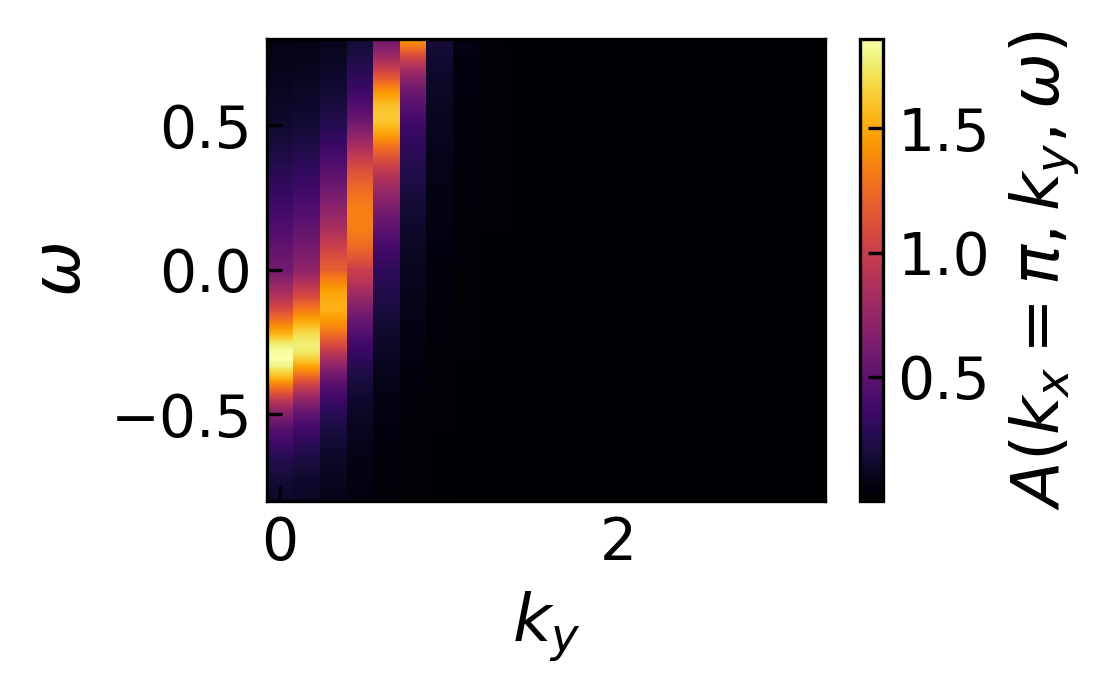

In [58]:
# 4. A(kpath, omega) heatmap
akpath_file = os.path.join(data_dir, 'spectra_akpath.csv')
df_path = pd.read_csv(akpath_file)

pivot_path = df_path.pivot(index='omega', columns='ky', values='A_val')
pivot_path.sort_index(ascending=True, inplace=True)
pivot_path = pivot_path.reindex(sorted(pivot_path.columns), axis=1)

omega_vals = pivot_path.index.values.astype(float)
ky_vals = pivot_path.columns.values.astype(float) 
Z_path = pivot_path.values

X, Y = np.meshgrid(ky_vals, omega_vals)
kx_val = df_path['kx'].iloc[0] if 'kx' in df_path.columns else np.pi

plt.figure(figsize=(3, 2), dpi=300)
pcm = plt.pcolormesh(X, Y, Z_path, shading='nearest', cmap='inferno', rasterized=True)
cbar = plt.colorbar(pcm)
cbar.set_label(rf'$A(k_x=\pi, k_y, \omega)$')
plt.xlabel(r'$k_y$')
plt.ylabel(r'$\omega$')
plt.show()


In [59]:
L = 40
n = 3
2-3.4*np.cos(2*np.pi*n/L)

-1.0294221822404506

Peak along kx=pi at omega=0.0000: ky=0.3142


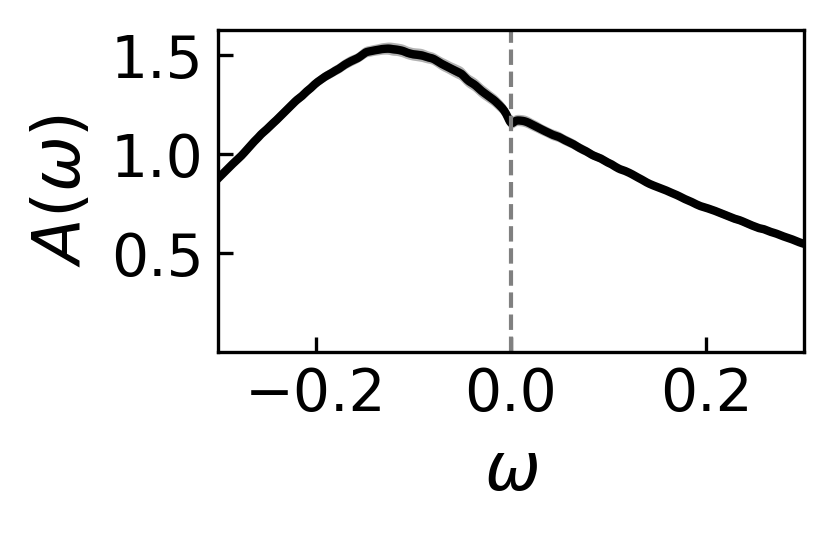

In [60]:
# 5. A(omega) at peak k along kx=pi path
omega_vals = pivot_path.index.values.astype(float)
ky_vals = pivot_path.columns.values.astype(float)
idx_omega0 = np.abs(omega_vals).argmin()
omega0 = omega_vals[idx_omega0]
A0 = pivot_path.iloc[idx_omega0].values 
idx_peak = np.nanargmax(A0)
ky_peak = ky_vals[idx_peak]

print(f'Peak along kx=pi at omega={omega0:.4f}: ky={ky_peak:.4f}')
df_peak = df_path[np.isclose(df_path['ky'], ky_peak)].sort_values('omega')

plt.figure(figsize=(3, 2), dpi=300)
plt.plot(df_peak['omega'], df_peak['A_val'], 'k-', label=f'Cut at $k_y={ky_peak:.2f}$')
if 'Error' in df_peak.columns:
    plt.fill_between(df_peak['omega'],
                     df_peak['A_val'] - df_peak['Error'],
                     df_peak['A_val'] + df_peak['Error'],
                     color='k', alpha=0.3, label='Error')

plt.xlabel(r'$\omega$')
plt.ylabel(r'$A(\omega)$')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlim(-0.3, 0.3)
plt.tight_layout()
plt.show()